In [2]:
# LONG-ONLY MOMENTUM STRATEGIES 
import pandas as pd
import numpy as np
import scipy.optimize as sco
import matplotlib.pyplot as plt
from pandas_datareader import data as pdr

In [3]:
# STEP 1: Load price data
data = pd.read_excel("C:\\Users\\ierad\\OneDrive\\Desktop\\DATA_PORT_clean.xlsx", index_col=0, parse_dates=True)

In [4]:
# STEP 2: Calculate 12-month momentum monthly returns
def calculate_returns(data, window=12):
    monthly_returns = data.resample('M').last().pct_change(periods=window).dropna()
    return monthly_returns

monthly_returns = calculate_returns(data)

In [5]:
# STEP 3: Select top 15 percentile stocks
def select_long_stocks(returns, long_percentile=85):
    selected_long = {}
    for date in returns.index:
        sorted_returns = returns.loc[date].dropna().sort_values()
        if len(sorted_returns) < 2:
            continue
        threshold = np.percentile(sorted_returns, long_percentile)
        selected = sorted_returns[sorted_returns >= threshold].index.tolist() #tolist to convert the selected stock in a list 
        selected_long[date] = selected
    return selected_long

selected_long = select_long_stocks(monthly_returns)


In [6]:
# STEP 4: Markowitz Optimization
def markowitz_optimization(returns):
    if returns.shape[0] < 2 or returns.shape[1] < 2:
        return None
    mu = returns.mean().values
    Sigma = returns.cov().values
    n = len(mu)
    def sharpe_ratio(weights):
        port_return = np.dot(weights, mu)
        port_risk = np.sqrt(weights.T @ Sigma @ weights)
        return -port_return / port_risk if port_risk > 0 else np.inf
    constraints = ({'type': 'eq', 'fun': lambda w: np.sum(w) - 1})
    bounds = tuple((0, 1) for _ in range(n))
    init_weights = np.ones(n) / n
    result = sco.minimize(sharpe_ratio, init_weights, method='SLSQP', bounds=bounds, constraints=constraints)
    return result.x if result.success else None

In [7]:
# STEP 5: Optimize monthly long-only portfolios
def optimize_long_portfolio(monthly_returns, selected_long):
    optimized_weights = {}
    for date in selected_long.keys():
        long_assets = selected_long[date]
        if len(long_assets) < 3:
            continue
        long_returns = monthly_returns[long_assets].dropna(axis=1)
        if long_returns.shape[1] < 2:
            continue
        weights = markowitz_optimization(long_returns)
        if weights is not None:
            weights /= np.sum(np.abs(weights))
            optimized_weights[date] = dict(zip(long_returns.columns, weights))
    return optimized_weights

optimized_long_weights = optimize_long_portfolio(monthly_returns, selected_long)

In [8]:
# STEP 6: Compute returns and simulate portfolio performance
daily_returns = data.pct_change()
portfolio_returns = pd.Series(0, index=daily_returns.index, dtype=float)
rebalance_dates = sorted(optimized_long_weights.keys())

for i, date in enumerate(rebalance_dates):
    next_date = rebalance_dates[i + 1] if i + 1 < len(rebalance_dates) else daily_returns.index[-1]
    date_range = daily_returns.loc[date:next_date].index
    weight_dict = optimized_long_weights[date]
    stocks = list(weight_dict.keys())
    weights = np.array([weight_dict[s] for s in stocks])
    returns_selected = daily_returns[stocks].loc[date_range].dropna(axis=1)
    common_stocks = list(returns_selected.columns)
    weight_vector = np.array([weight_dict[s] for s in common_stocks])
    abs_sum = np.abs(weight_vector).sum()
    if abs_sum > 0:
        weight_vector /= abs_sum
        portfolio_returns.loc[date_range] = (returns_selected[common_stocks] @ weight_vector)

portfolio_returns.replace([np.inf, -np.inf], np.nan, inplace=True)
portfolio_returns.fillna(0, inplace=True)
cumulative_returns = (1 + portfolio_returns).cumprod()

In [9]:
# STEP 7: Download benchmark from FRED (S&P 500)
start_date = cumulative_returns.index.min()
end_date = cumulative_returns.index.max()
sp500 = pdr.DataReader('SP500', 'fred', start=start_date, end=end_date)
sp500.rename(columns={'SP500': 'Close'}, inplace=True)
sp500['Daily Return'] = sp500['Close'].pct_change()
sp500['Cumulative Return'] = (1 + sp500['Daily Return']).cumprod()
sp500['Cumulative Return'].iloc[0] = 1.0

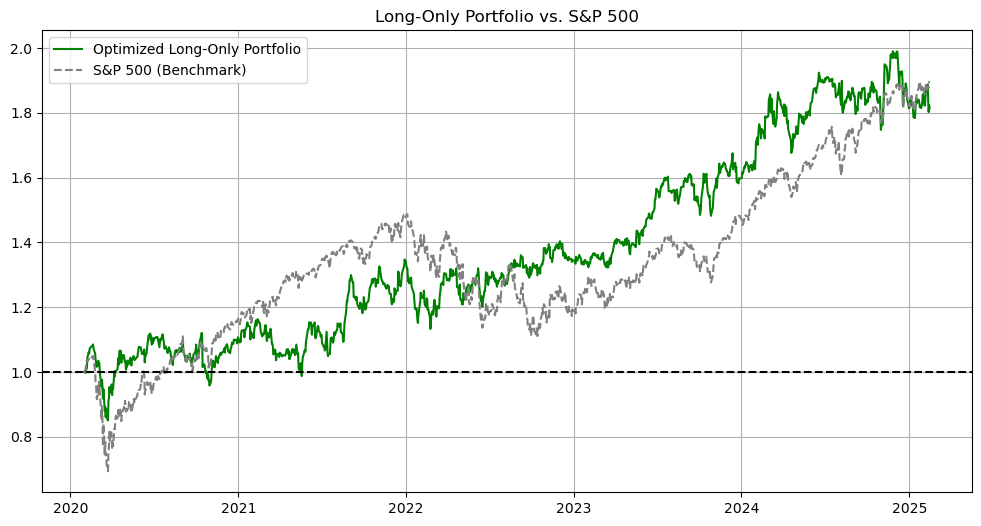

In [10]:
# STEP 8: Plot portfolio vs. benchmark
aligned_index = cumulative_returns.index.intersection(sp500.index)
aligned_index = aligned_index[aligned_index >= rebalance_dates[0]]  # taglia benchmark allineato

portfolio_aligned = cumulative_returns.loc[aligned_index]
benchmark_aligned = sp500.loc[aligned_index, 'Cumulative Return']

portfolio_aligned /= portfolio_aligned.iloc[0]
benchmark_aligned /= benchmark_aligned.iloc[0]

plt.figure(figsize=(12, 6))
plt.plot(portfolio_aligned, label="Optimized Long-Only Portfolio", color='green')
plt.plot(benchmark_aligned, label="S&P 500 (Benchmark)", color='gray', linestyle='--')
plt.axhline(y=1, color='black', linestyle='--')
plt.title("Long-Only Portfolio vs. S&P 500")
plt.legend()
plt.grid(True)
plt.show()

In [11]:
# STEP 9: Calculate drawdown and performance metrics
def calculate_monthly_drawdown(cumulative_returns):
    monthly_returns = cumulative_returns.resample('M').last()
    peak = monthly_returns.cummax()
    drawdown = (monthly_returns - peak) / peak
    return drawdown

def calculate_monthly_performance_metrics(cumulative_returns, risk_free_rate=0.02):
    monthly_returns = cumulative_returns.resample('M').last().pct_change().dropna()
    if monthly_returns.empty:
        return {"Error": "Not enough data to compute performance metrics."}
    total_return = cumulative_returns.iloc[-1] - 1
    num_months = len(monthly_returns)
    annualized_return = (1 + total_return) ** (12 / num_months) - 1 if num_months > 0 else np.nan
    annualized_volatility = monthly_returns.std() * np.sqrt(12) if num_months > 1 else np.nan
    sharpe_ratio = (annualized_return - risk_free_rate) / annualized_volatility if annualized_volatility else np.nan
    downside_std = monthly_returns[monthly_returns < 0].std()
    sortino_ratio = (annualized_return - risk_free_rate) / downside_std if downside_std else np.nan
    var_95 = np.percentile(monthly_returns, 5)
    drawdown_series = calculate_monthly_drawdown(cumulative_returns)
    max_drawdown = drawdown_series.min()
    return {
        "Total Return": total_return,
        "Annualized Return": annualized_return,
        "Annualized Volatility": annualized_volatility,
        "Sharpe Ratio": sharpe_ratio,
        "Sortino Ratio": sortino_ratio,
        "Value at Risk (95%)": var_95,
        "Max Drawdown": max_drawdown,
    }

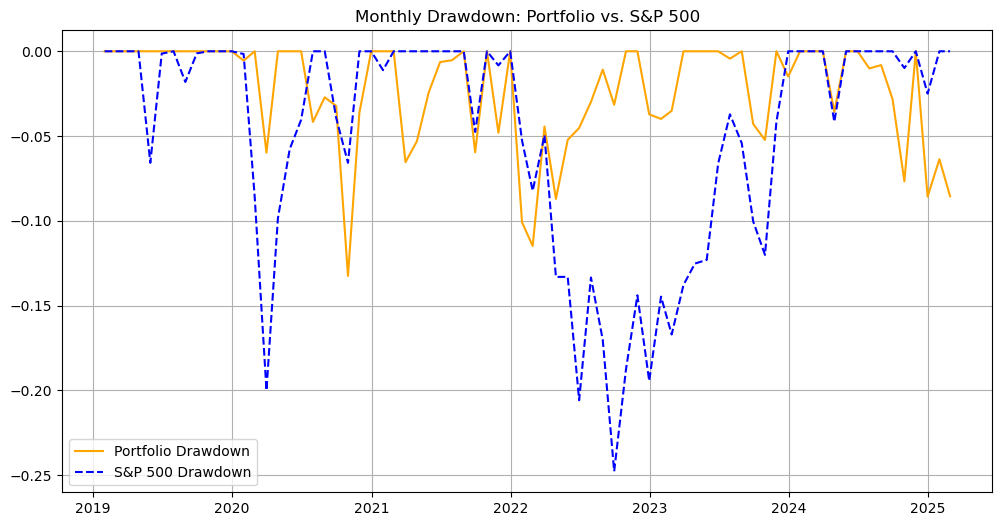


📊 Long-Only Portfolio Performance Metrics:
Total Return: 80.47%
Annualized Return: 10.19%
Annualized Volatility: 17.02%
Sharpe Ratio: 0.4814
Sortino Ratio: 2.7450
Value at Risk (95%): -6.20%
Max Drawdown: -13.25%


In [12]:
# STEP 10: Plot metrics
portfolio_drawdown = calculate_monthly_drawdown(cumulative_returns)
portfolio_metrics = calculate_monthly_performance_metrics(cumulative_returns)

sp500_drawdown = calculate_monthly_drawdown(sp500['Cumulative Return'])

plt.figure(figsize=(12, 6))
plt.plot(portfolio_drawdown, label="Portfolio Drawdown", color='orange')
plt.plot(sp500_drawdown, label="S&P 500 Drawdown", color='blue', linestyle='dashed')
plt.title("Monthly Drawdown: Portfolio vs. S&P 500")
plt.legend()
plt.grid(True)
plt.show()

print("\n📊 Long-Only Portfolio Performance Metrics:")
for k, v in portfolio_metrics.items():
    if isinstance(v, float):
        if "Return" in k or "Volatility" in k or "Drawdown" in k or "Value at Risk" in k:
            print(f"{k}: {v:.2%}")
        else:
            print(f"{k}: {v:.4f}")
    else:
        print(f"{k}: {v}")


In [ ]:
# Combined momentum 1 month - 1 year 

In [16]:
# STEP 11: Calculate 1-month momentum monthly returns
monthly_returns_1m = data.resample('M').last().pct_change(periods=1).dropna()

In [17]:
# STEP 12: select the top 15% 
selected_long_1m = select_long_stocks(monthly_returns_1m)

In [18]:
# STEP 13: Optimize the weight
optimized_long_weights_1m = optimize_long_portfolio(monthly_returns_1m, selected_long_1m)

In [19]:
# STEP 14: Combined momentum 
portfolio_returns_combined = pd.Series(0, index=daily_returns.index, dtype=float)
rebalance_dates_combined = sorted(set(optimized_long_weights.keys()).intersection(optimized_long_weights_1m.keys()))

for i, date in enumerate(rebalance_dates_combined):
    next_date = rebalance_dates_combined[i + 1] if i + 1 < len(rebalance_dates_combined) else daily_returns.index[-1]
    date_range = daily_returns.loc[date:next_date].index

    weights_12m = optimized_long_weights[date]
    weights_1m = optimized_long_weights_1m[date]

    all_stocks = list(set(weights_12m.keys()).union(weights_1m.keys()))
    w_12m = np.array([weights_12m.get(s, 0) for s in all_stocks])
    w_1m = np.array([weights_1m.get(s, 0) for s in all_stocks])

    combined_weights = 0.5 * w_12m + 0.5 * w_1m
    if np.sum(np.abs(combined_weights)) > 0:
        combined_weights /= np.sum(np.abs(combined_weights))

    returns_selected = daily_returns[all_stocks].loc[date_range].dropna(axis=1)
    common_stocks = list(returns_selected.columns)
    weight_vector = np.array([combined_weights[all_stocks.index(s)] for s in common_stocks])
    abs_sum = np.abs(weight_vector).sum()
    if abs_sum > 0:
        weight_vector /= abs_sum
        portfolio_returns_combined.loc[date_range] = (returns_selected[common_stocks] @ weight_vector)


In [20]:
# STEP 15: Compute cumulative returns
cumulative_returns_combined = (1 + portfolio_returns_combined).cumprod()

In [26]:
# STEP 16: Aling the dataset to the same starting point
start_date = rebalance_dates[0]

# Slice all series
portfolio_12m_cut = cumulative_returns.loc[start_date:]
portfolio_combined_cut = cumulative_returns_combined.loc[start_date:]
benchmark_cut = sp500['Cumulative Return'].loc[start_date:]

# Normalize from same start point for plotting
portfolio_12m_cut /= portfolio_12m_cut.iloc[0]
portfolio_combined_cut /= portfolio_combined_cut.iloc[0]
benchmark_cut /= benchmark_cut.iloc[0]


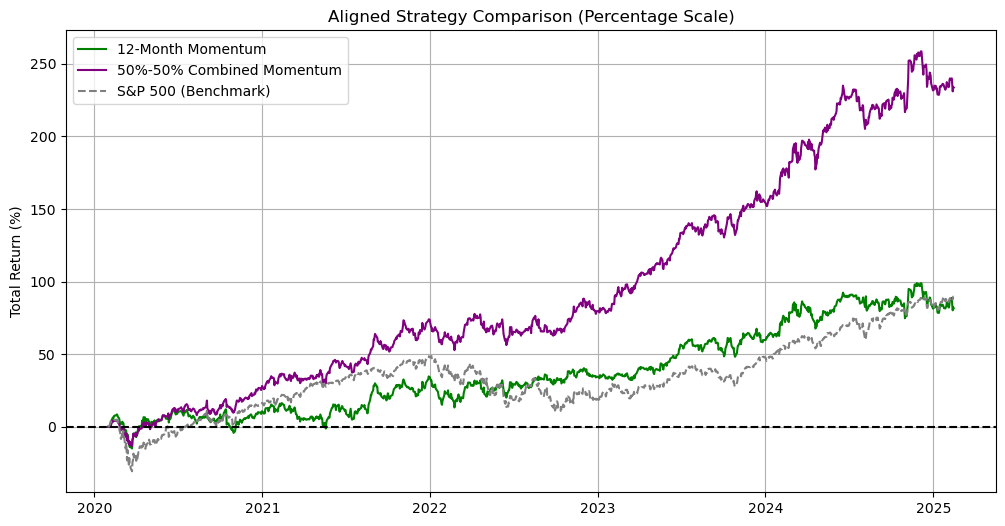

In [29]:
# STEP 17: Computing the  performance metrics
# Recalculate performance metrics on aligned period
portfolio_metrics_12m = calculate_monthly_performance_metrics(portfolio_12m_cut)
portfolio_metrics_combined = calculate_monthly_performance_metrics(portfolio_combined_cut)
portfolio_metrics_sp500 = calculate_monthly_performance_metrics(benchmark_cut)

# Plot updated aligned comparison
plt.figure(figsize=(12, 6))

# Calcola serie in termini percentuali (partenza = 0%)
portfolio_12m_pct = (portfolio_12m_cut / portfolio_12m_cut.iloc[0] - 1) * 100
portfolio_combined_pct = (portfolio_combined_cut / portfolio_combined_cut.iloc[0] - 1) * 100
benchmark_pct = (benchmark_cut / benchmark_cut.iloc[0] - 1) * 100

plt.plot(portfolio_12m_pct, label="12-Month Momentum", color='green')
plt.plot(portfolio_combined_pct, label="50%-50% Combined Momentum", color='purple')
plt.plot(benchmark_pct, label="S&P 500 (Benchmark)", color='gray', linestyle='--')
plt.axhline(y=0, color='black', linestyle='--')

plt.title("Aligned Strategy Comparison (Percentage Scale)")
plt.ylabel("Total Return (%)")
plt.legend()
plt.grid(True)
plt.show()

In [30]:
# Create updated summary table
summary_table = pd.DataFrame({
    "12M Momentum": {
        "Total Return": portfolio_metrics_12m["Total Return"],
        "Annualized Volatility": portfolio_metrics_12m["Annualized Volatility"],
        "Sharpe Ratio": portfolio_metrics_12m["Sharpe Ratio"]
    },
    "Combined Momentum": {
        "Total Return": portfolio_metrics_combined["Total Return"],
        "Annualized Volatility": portfolio_metrics_combined["Annualized Volatility"],
        "Sharpe Ratio": portfolio_metrics_combined["Sharpe Ratio"]
    },
    "S&P 500": {
        "Total Return": portfolio_metrics_sp500["Total Return"],
        "Annualized Volatility": portfolio_metrics_sp500["Annualized Volatility"],
        "Sharpe Ratio": portfolio_metrics_sp500["Sharpe Ratio"]
    }
}).T

# Format table
summary_table["Total Return"] = summary_table["Total Return"].apply(lambda x: f"{x:.2%}")
summary_table["Annualized Volatility"] = summary_table["Annualized Volatility"].apply(lambda x: f"{x:.2%}")
summary_table["Sharpe Ratio"] = summary_table["Sharpe Ratio"].apply(lambda x: f"{x:.4f}")

# Display summary table
print("\n📊 Aligned Strategy Performance Summary:")
print(summary_table)



📊 Aligned Strategy Performance Summary:
                  Total Return Annualized Volatility Sharpe Ratio
12M Momentum            81.47%                18.57%       0.5622
Combined Momentum      233.63%                15.63%       1.5833
S&P 500                 89.57%                18.04%       0.6325
